Results:
a) Probability of 3 patients:  0.007567 (0.76%)
b) Probability of 15 patients: 0.034718 (3.47%)
c) Probability of 4 patients:  0.018917 (1.89%)



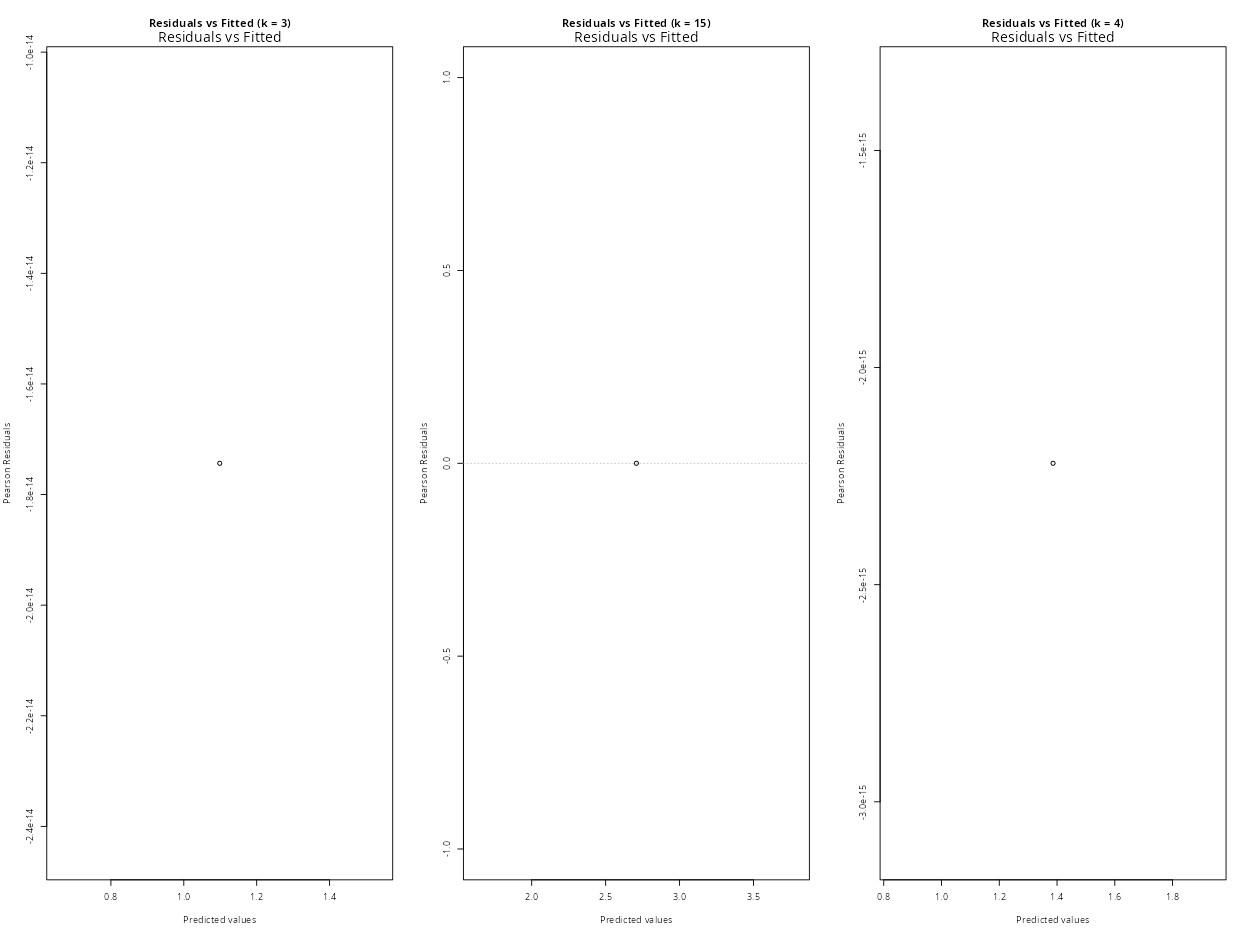

In [ ]:
# Define the average rate (lambda)
lambda <- 10

# -------------------------------------------------------------------------
# Calculations using built-in Poisson function (dpois)
# -------------------------------------------------------------------------
prob_a <- dpois(3, lambda)
prob_b <- dpois(15, lambda)
prob_c <- dpois(4, lambda)

# Display results in the console
cat("Results:\n")
cat(sprintf("a) Probability of 3 patients:  %.6f (%.2f%%)\n", prob_a, prob_a * 100))
cat(sprintf("b) Probability of 15 patients: %.6f (%.2f%%)\n", prob_b, prob_b * 100))
cat(sprintf("c) Probability of 4 patients:  %.6f (%.2f%%)\n\n", prob_c, prob_c * 100))



In [3]:
# 1. Carga de librerías y datos de salud reales
if(!require(MASS)) install.packages("MASS")
library(MASS)

data("birthwt")
df <- birthwt

# 2. Análisis Exploratorio de Datos (EDA) y Preparación
# Convertimos las variables categóricas a factores para su correcto modelado
df$low   <- factor(df$low, levels = c(0, 1), labels = c("Normal", "BajoPeso"))
df$smoke <- factor(df$smoke, levels = c(0, 1), labels = c("No", "Si"))

summary(df[, c("low", "age", "lwt", "smoke")])

# 3. Ajuste del Modelo de Regresión Logística Múltiple
# La función glm() requiere especificar family = binomial para invocar el enlace logit
modelo_log <- glm(low ~ age + lwt + smoke, data = df, family = binomial(link = "logit"))

# 4. Inspección de Resultados Estadísticos Esenciales
summary(modelo_log)

# 5. Extracción de Coeficientes y Cálculo de Odds Ratios (OR) con sus IC 95%
coef_regresion <- coef(modelo_log)
intervalos_ic  <- confint.default(modelo_log) # IC basados en el error estándar asintótico (Wald)

# Construcción de la tabla de estimadores epidemiológicos (exponenciando los betas)
tabla_or <- exp(cbind(OR = coef_regresion, intervalos_ic))
print(tabla_or)

Loading required package: MASS
                   OR     2.5 %     97.5 %
(Intercept) 3.9283727 0.5381107 28.6783220
age         0.9617559 0.9020038  1.0254663
lwt         0.9879348 0.9761269  0.9998856
smokeSi     1.9557304 1.0325744  3.7042189


In [4]:

library(faraway)
data(pima)

# Modelo para predecir diabetes según IMC
modelo_diabetes <- glm(test ~ bmi + age, data = pima, family = binomial)

# Probabilidades predichas para nuevos casos
nuevos_datos <- data.frame(bmi = c(25, 35), age = c(30, 45))
predict(modelo_diabetes, nuevos_datos, type = "response")

        1         2 
0.1708942 0.5218144 